#**AI In Genomics** *Rachel Ren & Alex Manko*

## Preliminary Notebook Set-Up


In [ ]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
!pip install torch torchvision
import torch

In [ ]:
#Mount Google Drive Dataset
from google.colab import drive
drive.mount('/content/drive')
data = pd.read_csv('/content/drive/MyDrive/Code/LINCS/lincs_with_smiles.csv')
print(data.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
                     cid       780      7849      6193        23      9552  \
0  REP.A026_HELA_24H:I16  1.023382  0.207262 -0.044541  0.700534  1.482482   
1  REP.A022_HELA_24H:F17 -0.446107 -0.356715  0.899180  0.772058  0.567571   
2  REP.A020_HT29_24H:F03  5.094128  1.451962 -1.571155  0.054068  3.915428   
3  REP.A008_MCF7_24H:D23 -0.311510  0.014857  0.687141  0.692091 -1.629638   
4  REP.A009_HA1E_24H:I01  1.071189  0.218189 -0.282758 -0.140337  0.486586   

        387     10921     10285       533  ...      6915      6253      7264  \
0  0.039872  0.278983  0.077730 -0.581898  ... -0.360170 -0.014861  0.245309   
1 -1.080960  0.849523 -0.667825  1.322551  ... -0.022798 -0.045133  1.019796   
2 -1.872908 -1.731748 -1.688446 -1.448363  ...  3.018867  0.694927 -0.005210   
3 -0.890905  0.156909  0.252236 -0.572326  ... -0.146394  0.072722 -0.476075   
4 

In [ ]:
print(data.shape)

(18755, 981)


In [ ]:
# Load TCM compounds
tcm_df = pd.read_csv('/content/drive/MyDrive/Code/TCM/tcm_smiles.csv')
tcm_smiles = set(tcm_df['SMILES'].dropna().tolist())

# Remove overlapping compounds from LINCS training data
before = len(data)
data = data[~data['SMILES'].isin(tcm_smiles)]
after = len(data)
print(f"Removed {before - after} overlapping compounds")
print(f"Training data size: {after}")

Removed 64 overlapping compounds
Training data size: 18691


## Feature Representation

In [ ]:
#install rdkit
!pip install rdkit

In [ ]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.DataStructs import ConvertToNumpyArray

def smiles_to_morgan(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fp = generator.GetFingerprint(mol)
    arr = np.zeros((n_bits,), dtype=np.int8)
    ConvertToNumpyArray(fp, arr)
    return arr

data["fingerprint"] = data["SMILES"].apply(smiles_to_morgan)

In [ ]:
print(data)

                         cid       780      7849      6193        23  \
0      REP.A026_HELA_24H:I16  1.023382  0.207262 -0.044541  0.700534   
1      REP.A022_HELA_24H:F17 -0.446107 -0.356715  0.899180  0.772058   
2      REP.A020_HT29_24H:F03  5.094128  1.451962 -1.571155  0.054068   
3      REP.A008_MCF7_24H:D23 -0.311510  0.014857  0.687141  0.692091   
4      REP.A009_HA1E_24H:I01  1.071189  0.218189 -0.282758 -0.140337   
...                      ...       ...       ...       ...       ...   
18750   LJP007_HUES3_24H:H14  0.511942  0.384216 -0.723179 -0.047524   
18751  REP.A015_HT29_24H:D20 -1.638968 -0.730384 -1.594706 -0.596255   
18752  REP.A005_MCF7_24H:J12  0.977176 -0.198668 -0.082434 -1.237465   
18753  REP.A021_HT29_24H:N11  0.525100 -0.554316 -0.013229  0.436254   
18754  REP.A006_A375_24H:O09  0.648450 -0.404669  0.045473  0.674552   

           9552       387     10921     10285       533  ...      6253  \
0      1.482482  0.039872  0.278983  0.077730 -0.581898  ... 

# Baseline Model (No dimensionality Reduction)

In [ ]:
#X will be the fingerprint
X = np.stack(data["fingerprint"].values).astype(np.float32)
print("X shape:", X.shape)

exclude_cols = ["cid", "SMILES", "fingerprint"]

gene_cols = [col for col in data.columns
             if col not in exclude_cols and pd.api.types.is_numeric_dtype(data[col])]

gene_matrix = data[gene_cols].copy()

def read_gmt(gmt_path):
    pathways = {}
    with open(gmt_path, "r") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) < 3:
                continue
            pathway_name = parts[0]
            genes = parts[2:]
            pathways[pathway_name] = genes
    return pathways

#gmt_path = "/content/drive/MyDrive/Code/Disease Signature (MSigDB)/c2.all.v2026.1.Hs.symbols.gmt"
gmt_path = "/content/drive/MyDrive/Code/Disease Signature (MSigDB)/c2.all.v2026.1.Hs.entrez.gmt"
pathways_raw = read_gmt(gmt_path)

gene_set = set(gene_cols)
pathway_to_genes = {
    pname: [g for g in genes if g in gene_set]
    for pname, genes in pathways_raw.items()
}

pathway_to_genes = {
    pname: genes for pname, genes in pathway_to_genes.items()
    if len(genes) >= 5
}

sorted_pathways = sorted(pathway_to_genes.items(), key=lambda x: len(x[1]), reverse=True)
selected_pathways = dict(sorted_pathways[:100])

pathway_score_df = pd.DataFrame(index=data.index)

for pname, genes in selected_pathways.items():
    pathway_score_df[pname] = gene_matrix[genes].mean(axis=1)

y_cols = list(pathway_score_df.columns)
y = pathway_score_df.values.astype(np.float32)

print("Number of pathway outputs:", len(y_cols))
print("y shape:", y.shape)
print("First few pathways:", y_cols[:10])

X shape: (18691, 2048)
Number of pathway outputs: 100
y shape: (18691, 100)
First few pathways: ['PUJANA_BRCA1_PCC_NETWORK', 'DIAZ_CHRONIC_MYELOGENOUS_LEUKEMIA_UP', 'GRAESSMANN_APOPTOSIS_BY_DOXORUBICIN_DN', 'BLALOCK_ALZHEIMERS_DISEASE_UP', 'PUJANA_ATM_PCC_NETWORK', 'DODD_NASOPHARYNGEAL_CARCINOMA_UP', 'REACTOME_POST_TRANSLATIONAL_PROTEIN_MODIFICATION', 'KINSEY_TARGETS_OF_EWSR1_FLII_FUSION_UP', 'BLALOCK_ALZHEIMERS_DISEASE_DN', 'REACTOME_RNA_POLYMERASE_II_TRANSCRIPTION']


Train Validation Test Split

In [ ]:
#train test valiation split 70/15/15
from sklearn.model_selection import train_test_split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42)

#print sizes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (13082, 2048)
y_train shape: (13082, 100)
X_val shape: (2805, 2048)
y_val shape: (2805, 100)
X_test shape: (2804, 2048)
y_test shape: (2804, 100)


Making Data Loader

In [ ]:
#Making Data Loader
import torch
from torch.utils.data import Dataset, DataLoader

#make data loader given a batch size
def make_data_loader(X_arr, y_arr, batch_size, shuffle=True):
  #from nump
  x_tensor = torch.from_numpy(X_arr)
  y_tensor = torch.from_numpy(y_arr)
  dataset = torch.utils.data.TensorDataset(x_tensor, y_tensor)
  data_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
  return data_loader

Setting up the Model (not rigid)

In [ ]:
#simple MLP
#import net

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

#make the MLP class
class MLP(torch.nn.Module):
    def __init__(self, input_size, output_size,hidden_dims = (256, 512), dropout = 0.3):
        super(MLP, self).__init__()
        layers = []
        prev_dim = input_size
        for dim in hidden_dims:
            layers.append(torch.nn.Linear(prev_dim, dim))
            layers.append(torch.nn.ReLU())
            layers.append(torch.nn.Dropout(dropout))
            prev_dim = dim
        layers.append(torch.nn.Linear(prev_dim, output_size))
        self.net = torch.nn.Sequential(*layers)
    def forward(self, x):
      return self.net(x)




cuda


Setting up metrics

In [ ]:
#import scipy pearsonr
from scipy.stats import pearsonr

#mean compound pearson
def mean_compoundwise_pearson(y_true, y_pred):
    corrs = []
    for i in range(y_true.shape[0]):
        if np.std(y_true[i]) > 1e-8 and np.std(y_pred[i]) > 1e-8:
            corr, _ = pearsonr(y_true[i], y_pred[i])
            if not np.isnan(corr):
                corrs.append(corr)
    return np.mean(corrs) if len(corrs) > 0 else np.nan

#mean pathwaywise pearson
def mean_pathwaywise_pearson(y_true, y_pred):
    corrs = []
    for j in range(y_true.shape[1]):
        if np.std(y_true[:, j]) > 1e-8 and np.std(y_pred[:, j]) > 1e-8:
          corr, _ = pearsonr(y_true[:, j], y_pred[:, j])
          if not np.isnan(corr):
            corrs.append(corr)

    return np.mean(corrs) if len(corrs) > 0 else np.nan

#evaluate model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(model, loader, criterion):
    model.eval()
    total_loss = 0
    total_samples = 0
    all_true = []
    all_preds = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)

            loss = criterion(outputs, targets)
            batch_size = targets.size(0)

            total_loss += loss.item() * batch_size
            total_samples += batch_size

            all_true.append(targets.cpu().numpy())
            all_preds.append(outputs.cpu().numpy())

    y_true_stack = np.vstack(all_true)
    y_pred_stack = np.vstack(all_preds)

    mse = total_loss / total_samples
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_stack.flatten(), y_pred_stack.flatten())
    r2 = r2_score(y_true_stack.flatten(), y_pred_stack.flatten())

    mean_compound_pearson = mean_compoundwise_pearson(y_true_stack, y_pred_stack)
    mean_pathway_pearson = mean_pathwaywise_pearson(y_true_stack, y_pred_stack)

    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "mean_compound_pearson": mean_compound_pearson,
        "mean_pathway_pearson": mean_pathway_pearson
    }

def evaluate_loss(model, loader, criterion):
  model.eval()
  total_loss = 0
  total_samples = 0
  with torch.no_grad():
    for inputs, targets in loader:
      inputs, targets = inputs.to(device), targets.to(device)
      outputs = model(inputs)
      loss = criterion(outputs, targets)
      batch_size = targets.size(0)
      total_loss += loss.item() * batch_size
      total_samples += batch_size
  avg_loss = total_loss / total_samples
  return avg_loss




Setting up Automated Training

In [ ]:
#train_one_model takes in condig, all the data
#import copy method below this line
import copy
def train_one_model(config, X_train, y_train, X_val, y_val, input_size, output_size, epochs=500, patience=50):
  train_loader = make_data_loader(X_train, y_train, config["batch_size"], shuffle=True)
  val_loader = make_data_loader(X_val, y_val, config["batch_size"], shuffle=False)
  model = MLP(input_size, output_size, hidden_dims=config["hidden_dims"], dropout=config["dropout"]).to(device)
  optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
  criterion = torch.nn.MSELoss()
  best_val_loss = float("inf")
  best_model_state = None
  best_epoch = 0
  train_losses = []
  val_losses = []
  epochs_without_improvement = 0
  for epoch in range(epochs):
      model.train()
      running_loss = 0.0
      n = 0
      for inputs, targets in train_loader:
          inputs, targets = inputs.to(device), targets.to(device)
          optimizer.zero_grad()
          outputs = model(inputs)
          loss = criterion(outputs, targets)
          loss.backward()
          optimizer.step()
          batch_size = inputs.size(0)
          running_loss += loss.item() * batch_size
          n += batch_size
      train_loss = running_loss / n
      val_loss = evaluate_loss(model, val_loader, criterion)
      train_losses.append(train_loss)
      val_losses.append(val_loss)
      if val_loss < best_val_loss:
          best_val_loss = val_loss
          best_model_state = copy.deepcopy(model.state_dict())
          best_epoch = epoch + 1
          epochs_without_improvement = 0
      else:
          epochs_without_improvement += 1
      #print epoch and metrics
      print(f"Epoch {epoch+1}")
      print(f"Train Loss: {train_loss:.4f}")
      print(f"Val Loss: {val_loss:.4f}")
      if epochs_without_improvement >= patience:
          print(f"Early stopping at epoch {epoch+1}")
          break
  model.load_state_dict(best_model_state)
  last_val_metrics = evaluate_model(model, val_loader, criterion)
  last_val_metrics["best_val_mse"] = best_val_loss
  last_val_metrics["best_val_rmse"] = np.sqrt(best_val_loss)
  last_val_metrics["best_epoch"] = best_epoch
  last_val_metrics["train_losses"] = train_losses
  last_val_metrics["val_losses"] = val_losses
  return model, last_val_metrics
#
#


Hyperparamter Search

In [ ]:
from re import search
import itertools
import random
#, (512, 256, 128), (256, 128, 64),  (1024, 512),
#, 1e-2
#1e-3
#64,
search_space = {
    "hidden_dims": [(512, 256), (256, 512), (1024, 512, 256)],
    "dropout": [0.0, 0.1, 0.5],
    "lr": [1e-4, 1e-3],
    "weight_decay": [0.0, 1e-4, ],
    "batch_size": [128, 256]
}

#set up the condigs
conds = list(itertools.product(search_space["hidden_dims"],
                               search_space["dropout"], search_space["lr"], search_space["weight_decay"], search_space["batch_size"]))
#print count options
print(len(conds))
#empty list
results_list = []
best_model = None
best_cond = None
best_score = -float("inf")


72


Assessment

In [ ]:
#loop through options enumerated

for cond_num, cond in enumerate(conds):
  input_option = {"hidden_dims": cond[0], "dropout": cond[1], "lr": cond[2], "weight_decay": cond[3], "batch_size": cond[4]}
  print(f"Training model {cond_num+1} of {len(conds)}")
  model, metrics = train_one_model(input_option, X_train, y_train, X_val, y_val, input_size=X_train.shape[1], output_size=y_train.shape[1],epochs=500, patience=10)
  row = {**input_option, **metrics}
  results_list.append(row)
  if metrics["mean_pathway_pearson"] > best_score:
    best_score = metrics["mean_pathway_pearson"]
    best_model = model
    best_cond = input_option
    print(f"New best model with mean pathway pearson {best_score}")


Streaming output truncated to the last 5000 lines.
Train Loss: 0.0572
Val Loss: 0.0679
Epoch 49
Train Loss: 0.0569
Val Loss: 0.0678
Epoch 50
Train Loss: 0.0569
Val Loss: 0.0677
Epoch 51
Train Loss: 0.0569
Val Loss: 0.0679
Epoch 52
Train Loss: 0.0569
Val Loss: 0.0680
Epoch 53
Train Loss: 0.0569
Val Loss: 0.0678
Early stopping at epoch 53
Training model 35 of 72
Epoch 1
Train Loss: 0.1067
Val Loss: 0.0821
Epoch 2
Train Loss: 0.0713
Val Loss: 0.0760
Epoch 3
Train Loss: 0.0669
Val Loss: 0.0737
Epoch 4
Train Loss: 0.0648
Val Loss: 0.0723
Epoch 5
Train Loss: 0.0636
Val Loss: 0.0713
Epoch 6
Train Loss: 0.0629
Val Loss: 0.0711
Epoch 7
Train Loss: 0.0623
Val Loss: 0.0704
Epoch 8
Train Loss: 0.0618
Val Loss: 0.0700
Epoch 9
Train Loss: 0.0613
Val Loss: 0.0697
Epoch 10
Train Loss: 0.0610
Val Loss: 0.0693
Epoch 11
Train Loss: 0.0608
Val Loss: 0.0694
Epoch 12
Train Loss: 0.0606
Val Loss: 0.0692
Epoch 13
Train Loss: 0.0603
Val Loss: 0.0690
Epoch 14
Train Loss: 0.0601
Val Loss: 0.0690
Epoch 15
Train L

In [ ]:
print("Best hyperparameters:", best_cond)
print("Best validation pathway Pearson:", best_score)

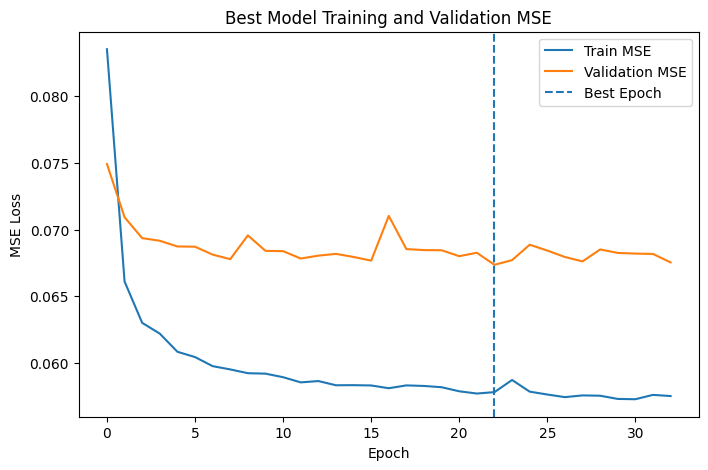

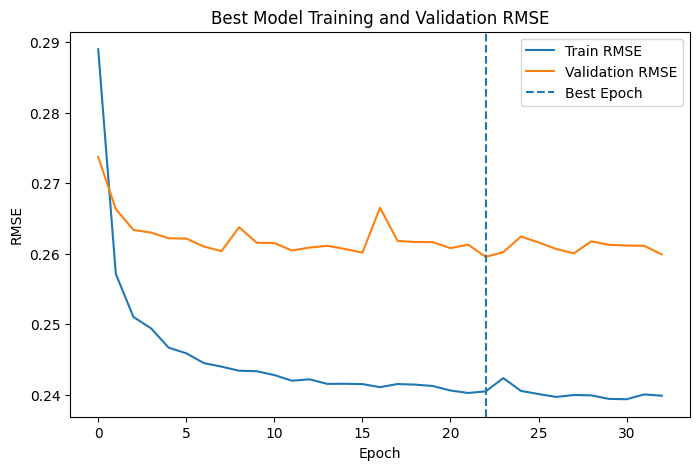

In [ ]:
best_metrics = [r for r in results_list
                if r["hidden_dims"] == best_cond["hidden_dims"]
                and r["dropout"] == best_cond["dropout"]
                and r["lr"] == best_cond["lr"]
                and r["weight_decay"] == best_cond["weight_decay"]
                and r["batch_size"] == best_cond["batch_size"]][0]

# MSE loss curves
plt.figure(figsize=(8,5))
plt.plot(best_metrics["train_losses"], label="Train MSE")
plt.plot(best_metrics["val_losses"], label="Validation MSE")
plt.axvline(best_metrics["best_epoch"] - 1, linestyle="--", label="Best Epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Best Model Training and Validation MSE")
plt.legend()
plt.show()

# RMSE curves
train_rmse = np.sqrt(best_metrics["train_losses"])
val_rmse = np.sqrt(best_metrics["val_losses"])

plt.figure(figsize=(8,5))
plt.plot(train_rmse, label="Train RMSE")
plt.plot(val_rmse, label="Validation RMSE")
plt.axvline(best_metrics["best_epoch"] - 1, linestyle="--", label="Best Epoch")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Best Model Training and Validation RMSE")
plt.legend()
plt.show()

Final metrics for best model:


,Train,Validation,Test
mse,0.055332,0.067359,0.059777
rmse,0.235228,0.259536,0.244494
mae,0.147949,0.161862,0.156764
r2,0.579803,0.524994,0.534374
mean_compound_pearson,0.412180,0.326642,0.321589
mean_pathway_pearson,0.642877,0.586789,0.587617


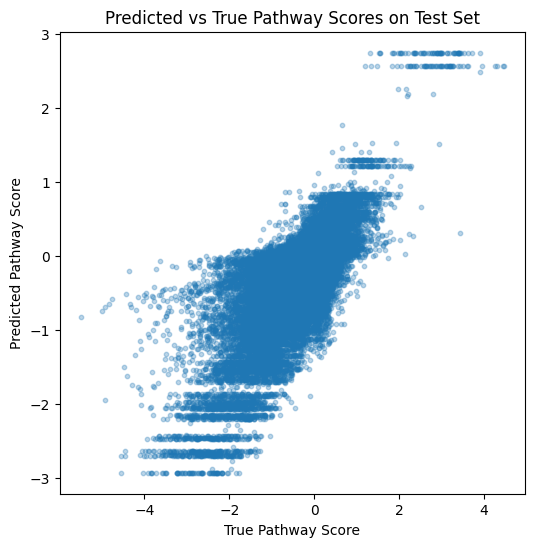

Mean pathway-wise Pearson on test set: 0.5876


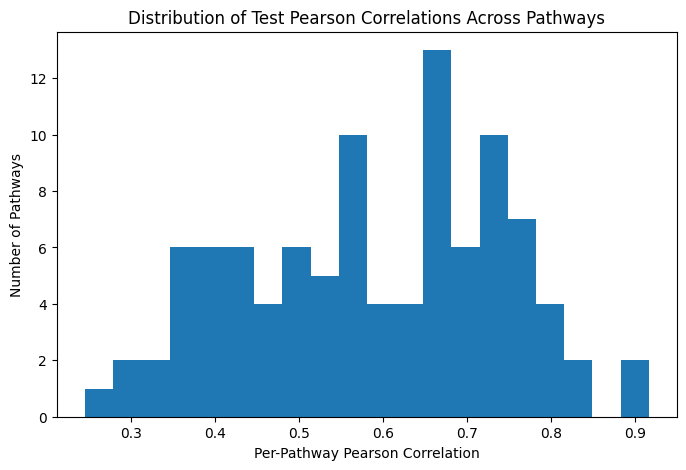

Top 10 best-predicted pathways:


,pathway,test_pearson
47,BUYTAERT_PHOTODYNAMIC_THERAPY_STRESS_DN,0.916021
25,BUYTAERT_PHOTODYNAMIC_THERAPY_STRESS_UP,0.905212
79,ENK_UV_RESPONSE_EPIDERMIS_DN,0.824142
88,RHEIN_ALL_GLUCOCORTICOID_THERAPY_DN,0.821754
54,FIGAROL_EGFR_TKI_DRUG_TOLERANT_CELL_DN,0.803094
76,BLUM_RESPONSE_TO_SALIRASIB_DN,0.797526
66,GOBERT_OLIGODENDROCYTE_DIFFERENTIATION_UP,0.796792
53,FEVR_CTNNB1_TARGETS_DN,0.793835
19,CASORELLI_ACUTE_PROMYELOCYTIC_LEUKEMIA_DN,0.770418
45,CAIRO_HEPATOBLASTOMA_CLASSES_UP,0.769404


Bottom 10 worst-predicted pathways:


,pathway,test_pearson
97,ONKEN_UVEAL_MELANOMA_DN,0.374149
78,WAKABAYASHI_ADIPOGENESIS_PPARG_RXRA_BOUND_8D,0.373472
92,GRUETZMANN_PANCREATIC_CANCER_UP,0.372781
42,REACTOME_ADAPTIVE_IMMUNE_SYSTEM,0.357781
58,SPIELMAN_LYMPHOBLAST_EUROPEAN_VS_ASIAN_DN,0.347545
32,MARSON_BOUND_BY_FOXP3_STIMULATED,0.317726
62,SCHLOSSER_SERUM_RESPONSE_DN,0.316510
48,KIM_ALL_DISORDERS_OLIGODENDROCYTE_NUMBER_CORR_UP,0.288664
70,YOSHIMURA_MAPK8_TARGETS_UP,0.285670
91,FORTSCHEGGER_PHF8_TARGETS_DN,0.245235


In [ ]:
# Evaluate best model on test set
train_loader = make_data_loader(X_train, y_train, batch_size=best_cond["batch_size"], shuffle=False)
val_loader = make_data_loader(X_val, y_val, batch_size=best_cond["batch_size"], shuffle=False)
test_loader = make_data_loader(X_test, y_test, batch_size=best_cond["batch_size"], shuffle=False)
best_model.eval()
all_true, all_preds = [], []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        all_preds.append(best_model(inputs).cpu().numpy())
        all_true.append(targets.cpu().numpy())

y_true_test = np.vstack(all_true)
y_pred_test = np.vstack(all_preds)

criterion = torch.nn.MSELoss()


train_final_metrics = evaluate_model(best_model, train_loader, criterion)
val_final_metrics = evaluate_model(best_model, val_loader, criterion)
test_final_metrics = evaluate_model(best_model, test_loader, criterion)

metrics_table = pd.DataFrame({
    "Train": train_final_metrics,
    "Validation": val_final_metrics,
    "Test": test_final_metrics
})

print("Final metrics for best model:")
display(metrics_table)
plt.figure(figsize=(6,6))
plt.scatter(y_true_test.flatten(), y_pred_test.flatten(), alpha=0.3, s=10)
plt.xlabel("True Pathway Score")
plt.ylabel("Predicted Pathway Score")
plt.title("Predicted vs True Pathway Scores on Test Set")
plt.show()
# Per-pathway (column-wise) Pearson
pathway_pearson_per_pathway = []
for j in range(y_true_test.shape[1]):
    if np.std(y_true_test[:, j]) > 1e-8 and np.std(y_pred_test[:, j]) > 1e-8:
        corr, _ = pearsonr(y_true_test[:, j], y_pred_test[:, j])
        pathway_pearson_per_pathway.append(corr)
    else:
        pathway_pearson_per_pathway.append(np.nan)

print(f"Mean pathway-wise Pearson on test set: {np.nanmean(pathway_pearson_per_pathway):.4f}")

plt.figure(figsize=(8,5))
plt.hist(pathway_pearson_per_pathway, bins=20)
plt.xlabel("Per-Pathway Pearson Correlation")
plt.ylabel("Number of Pathways")
plt.title("Distribution of Test Pearson Correlations Across Pathways")
plt.show()

pathway_perf_df = pd.DataFrame({
    "pathway": y_cols,
    "test_pearson": pathway_pearson_per_pathway
}).sort_values("test_pearson", ascending=False)

print("Top 10 best-predicted pathways:")
display(pathway_perf_df.head(10))

print("Bottom 10 worst-predicted pathways:")
display(pathway_perf_df.tail(10))

In [ ]:
PEARSON_THRESHOLD = 0.4
passing = {k: v for k, v in zip(y_cols, pathway_pearson_per_pathway) if v >= PEARSON_THRESHOLD}
print(f"{len(passing)}/{len(y_cols)} pathways meet threshold >= {PEARSON_THRESHOLD}")

84/100 pathways meet threshold >= 0.4


Apply to TCM

In [ ]:
tcm_df["fingerprint"] = tcm_df["SMILES"].apply(smiles_to_morgan)
tcm_df = tcm_df[tcm_df["fingerprint"].notna()].reset_index(drop=True)
X_tcm = np.stack(tcm_df["fingerprint"].values).astype(np.float32)

best_model.eval()
with torch.no_grad():
    tcm_preds = best_model(torch.from_numpy(X_tcm).to(device)).cpu().numpy()

tcm_pathway_df = pd.DataFrame(tcm_preds, columns=y_cols)
tcm_pathway_df.insert(0, "SMILES", tcm_df["SMILES"].values)
print(tcm_pathway_df.head())

disease_pathways = read_gmt(gmt_path)  # reuses your existing gmt_path variable
target_pathways = [p for p in disease_pathways.keys() if p in y_cols]
print(f"Matching disease pathways: {len(target_pathways)}")

tcm_pathway_df["disease_score"] = tcm_pathway_df[target_pathways].mean(axis=1)
top_tcm = tcm_pathway_df[["SMILES", "disease_score"]].sort_values("disease_score", ascending=False)
print(top_tcm.head(20))

                                              SMILES  \
0                        C=CCC1=CC(OC)=C(OC)C(OC)=C1   
1                            C1=CC=C2C3=CNSC3=NC2=C1   
2  CC(=O)C1=C(O)C(CC2=C(O)C(C)(C)C(=O)C(C(C)=O)=C...   
3                                    C=C(CC)CCCCCCCC   
4                  COC1=CC(O)=CC(CCC2=CC=CC=C2OC)=C1   

   PUJANA_BRCA1_PCC_NETWORK  DIAZ_CHRONIC_MYELOGENOUS_LEUKEMIA_UP  \
0                 -0.007518                              0.023412   
1                 -0.028947                             -0.049842   
2                  0.034224                              0.032766   
3                  0.039232                              0.049147   
4                  0.027192                              0.024641   

   GRAESSMANN_APOPTOSIS_BY_DOXORUBICIN_DN  BLALOCK_ALZHEIMERS_DISEASE_UP  \
0                                0.006385                       0.056557   
1                               -0.006226                      -0.021125   
2                   

ChatGPT links

https://chatgpt.com/share/6a05268e-4e04-83ea-a3fc-ac7b5563969a
https://chatgpt.com/share/6a052742-02a4-83ea-8a17-bb89b647ee7d
https://chatgpt.com/share/6a052c27-8a88-83ea-96b2-eafcc7f048bb
https://chatgpt.com/share/6a052cdf-d714-83ea-9d46-ed598a57710e